### CNN 활용 - 2 : 이미지 증강(Image Augmentation)

In [1]:
# horse-or-human classification model with CNN
# train : 1027 images [horse(500) + human(527)] , 300*300 pixels
# validation : 256 images [horse(128) + human(128)] , 300*300 pixels

In [2]:
# # ! pip install Augmentor
# import Augmentor

# # ! mkdir augmentation_test
# # 미리 'augmentation_test' 폴더를 만들어 놓는다

# # 증강 시킬 이미지 폴더 경로
# img = Augmentor.Pipeline('augmentation_test/')
# print(type(img))   # <class 'Augmentor.Pipeline.Pipeline'>

# # 좌우 반전
# img.flip_left_right(probability=1.0)

# # 상하 반전
# img.flip_top_bottom(probability=1.0)

# # 왜곡
# img.random_distortion(probability=1.0,grid_width=10,grid_height=10,magnitude=8)

# # 증강 실행, 출력 이미지 갯수를 설정
# img.sample(100)

In [3]:
import tensorflow as tf
import urllib
import zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop

In [4]:
# Colab용 : Linux/GPU사용 
# !wget --no-check-certificate \
#     https://storage.googleapis.com/laurencemoroney-blog.appspot.com/horse-or-human.zip \
#     -O /tmp/horse-or-human.zip

# !wget --no-check-certificate \
#     https://storage.googleapis.com/laurencemoroney-blog.appspot.com/validation-horse-or-human.zip \
#     -O /tmp/validation-horse-or-human.zip

In [5]:
# horse-or-human 데이터셋 다운로드 , Windows용, liux(Coloab)도 가능
_TRAIN_URL = "https://storage.googleapis.com/download.tensorflow.org/data/horse-or-human.zip"
_TEST_URL = "https://storage.googleapis.com/download.tensorflow.org/data/validation-horse-or-human.zip"
urllib.request.urlretrieve(_TRAIN_URL, 'horse-or-human.zip')
urllib.request.urlretrieve(_TEST_URL, 'validation-horse-or-human.zip')

('validation-horse-or-human.zip', <http.client.HTTPMessage at 0x227eea48a60>)

In [6]:
# 압축해제
local_zip = 'horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip,'r')
zip_ref.extractall('tmp/horse-or-human/')
zip_ref.close()

local_zip = 'validation-horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip,'r')
zip_ref.extractall('tmp/validation-horse-or-human/')
zip_ref.close()

train_dir = 'tmp/horse-or-human/'
validation_dir = 'tmp/validation-horse-or-human/'

In [7]:
# 이미지 데이터 경로 설정
import os

# Directory with our training horse pictures
train_horse_dir = os.path.join('tmp/horse-or-human/horses')

# Directory with our training human pictures
train_human_dir = os.path.join('tmp/horse-or-human/humans')

# Directory with our training horse pictures
validation_horse_dir = os.path.join('tmp/validation-horse-or-human/horses')

# Directory with our training human pictures
validation_human_dir = os.path.join('tmp/validation-horse-or-human/humans')

train_horse_names = os.listdir(train_horse_dir)
# print(train_horse_names[:10])

train_human_names = os.listdir(train_human_dir)
# print(train_human_names[:10])

validation_horse_names = os.listdir(validation_horse_dir)
# print(validation_horse_names[:10])

validation_human_names = os.listdir(validation_human_dir)
# print(validation_human_names[:10])

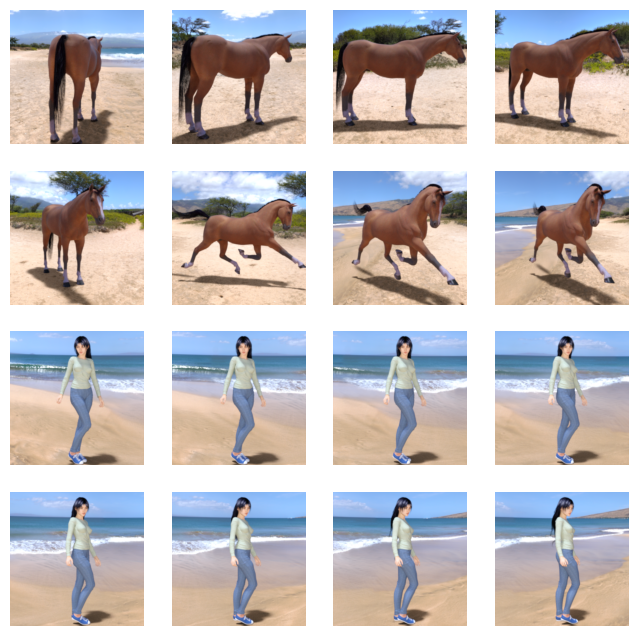

In [8]:
# 데이터 시각화 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Parameters for our graph; we'll output images in a 4x4 configuration
nrows = 4
ncols = 4

# Index for iterating over images
pic_index = 15  # 시작 인덱스

# Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols*2, nrows*2)

pic_index += 8
next_horse_pix = [os.path.join(train_horse_dir, fname) 
                for fname in train_horse_names[pic_index-8:pic_index]]
next_human_pix = [os.path.join(train_human_dir, fname) 
                for fname in train_human_names[pic_index-8:pic_index]]

# print(next_horse_pix)
# print(next_human_pix)

for i, img_path in enumerate(next_horse_pix+next_human_pix):  # 16회 반복
    # Set up subplot; subplot indices start at 1
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off') # Don't show axes (or gridlines)

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

### CNN Model 구현

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(300,300,3)),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),    
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),    
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),    
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=RMSprop(learning_rate=0.001),
             loss='binary_crossentropy',
             metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 298, 298, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 149, 149, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 147, 147, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 73, 73, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 71, 71, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 35, 35, 64)       0

### 텐서플로 이미지 증강 구현

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255)  # ImageDataGenerator

validation_datagen = ImageDataGenerator(rescale=1./255)

# train data의 generator
train_generator = train_datagen.flow_from_directory(
                  train_dir,  # 이미지 파일 디렉터리 경로,'tmp/horse-or-human/'
                  target_size = (300,300),  # resize될 크기
                  batch_size = 128,
                  class_mode='binary')      # 이진 분류   
type(train_generator)  # keras.preprocessing.image.DirectoryIterator,' __next__'지원

# validation data의 generator
validation_generator = validation_datagen.flow_from_directory(
                  validation_dir,  # 이미지 파일 디렉터리 경로, 'tmp/validation-horse-or-human/'
                  target_size = (300,300),  # resize될 크기
                  batch_size = 32,
                  class_mode='binary')      # 이진 분류 

print(train_generator) # DirectoryIterator object, ' __next__'지원
# 실제 사용 시점(학습시)에 데이터 생성
# fit 호출시 1 epoch 마다 train 이미지 1027개 생성  : 15 epochs 일 경우 총 15*1027 증강 이미지 생성
# fit 호출시 1 epoch 마다 validation 이미지 256개 생성  : 15 epochs 일 경우 총 15*256 증강 이미지 생성

Found 1027 images belonging to 2 classes.
Found 256 images belonging to 2 classes.


In [ ]:
# 학습, RTX 3060 약 2분 소요
history = model.fit(
          train_generator,    # X
          steps_per_epoch=8,  # 1027/128, train image number/train batch_size
          epochs = 15,
          verbose=1,
          validation_data=validation_generator,
          validation_steps=8) # 256/32, validation image number/validation batch_size

Epoch 1/15
8/8 [==============================] - 26s 2s/step - loss: 1.0119 - accuracy: 0.5573 - val_loss: 0.6822 - val_accuracy: 0.5000
Epoch 2/15
8/8 [==============================] - 5s 610ms/step - loss: 0.7081 - accuracy: 0.5317 - val_loss: 0.6595 - val_accuracy: 0.8047
Epoch 3/15
8/8 [==============================] - 6s 705ms/step - loss: 0.6667 - accuracy: 0.6051 - val_loss: 0.4363 - val_accuracy: 0.8594
Epoch 4/15
8/8 [==============================] - 6s 731ms/step - loss: 1.6554 - accuracy: 0.7720 - val_loss: 0.5185 - val_accuracy: 0.8008
Epoch 5/15
8/8 [==============================] - 6s 681ms/step - loss: 0.4495 - accuracy: 0.8131 - val_loss: 0.4922 - val_accuracy: 0.8047
Epoch 6/15
8/8 [==============================] - 5s 637ms/step - loss: 0.3315 - accuracy: 0.8828 - val_loss: 1.0266 - val_accuracy: 0.8008
Epoch 7/15
8/8 [==============================] - 5s 605ms/step - loss: 0.1696 - accuracy: 0.9288 - val_loss: 0.7837 - val_accuracy: 0.8984
Epoch 8/15
8/8 [======

### 학습 결과 시각화

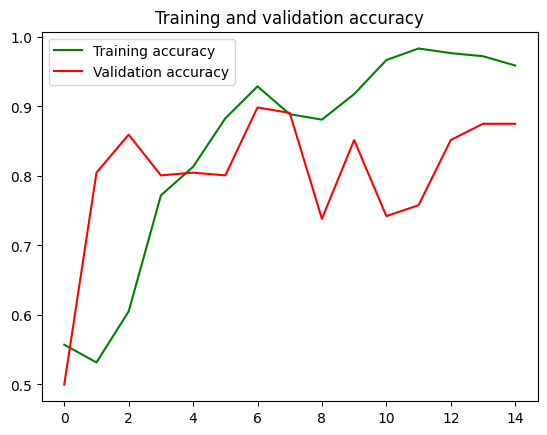

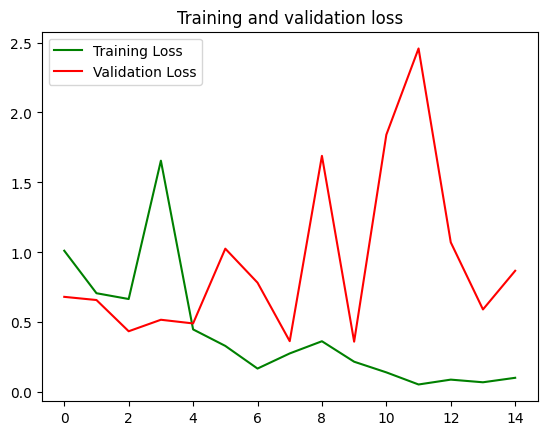

In [12]:
#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc      = history.history[     'accuracy' ]
val_acc  = history.history[ 'val_accuracy' ]
loss     = history.history[    'loss' ]
val_loss = history.history['val_loss' ]

epochs   = range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot(epochs, acc, 'g', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot(epochs, loss, 'g', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

### 이미지 분류 예측 

In [13]:
# 참고 소스
import numpy as np
from tensorflow.keras.preprocessing import image
def image_predict(file_name):
    path = 'horse-or-human예측용이미지/' + file_name
    img = image.load_img(path, target_size=(300, 300))
    x = image.img_to_array(img)   # 2차원 ndarray로 변환
    x = np.expand_dims(x, axis=0) # 3차원으로 변환
    images = np.vstack([x])       # 4차원으로 변환
    classes = model.predict(images, batch_size=10)
    # print(classes[0],end=' ')
    if classes[0] == 1.0:
        print(file_name ,': human')
    else:
        print(file_name ,': horse')
        
image_predict('말01.jpg')        
image_predict('말02.jpg') 
image_predict('기린.jpg')    
image_predict('말과사람.jpg')
image_predict('말과사람02.jpg')
image_predict('말과사람06.jpg')
image_predict('사람01.jpg')
image_predict('사람02.jpg')
image_predict('사람12.jpg')
image_predict('말타기게임하는사람.jpg')

1/1 [==============================] - 0s 404ms/step
말01.jpg : horse
1/1 [==============================] - 0s 20ms/step
말02.jpg : horse
1/1 [==============================] - 0s 19ms/step
기린.jpg : horse
1/1 [==============================] - 0s 8ms/step
말과사람.jpg : horse
1/1 [==============================] - 0s 23ms/step
말과사람02.jpg : human
1/1 [==============================] - 0s 16ms/step
말과사람06.jpg : human
1/1 [==============================] - 0s 20ms/step
사람01.jpg : horse
1/1 [==============================] - 0s 17ms/step
사람02.jpg : human
1/1 [==============================] - 0s 15ms/step
사람12.jpg : horse
1/1 [==============================] - 0s 15ms/step
말타기게임하는사람.jpg : horse


### 모델 개선

In [14]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self,epoch,logs={}):
        if(logs.get('accuracy') > 0.99):
            print("\nReached 99.9% accuracy so cancelling training!")  
            self.model.stop_training=True
            
callbacks = myCallback()

#### 텐서플로 이미지 증강 구현

In [12]:
# ! mkdir tmp\saved_train_image
# ! mkdir tmp\saved_val_image

In [15]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

validation_datagen = ImageDataGenerator(rescale=1./255)

# train data의 generator
train_generator = train_datagen.flow_from_directory(
                  train_dir,  # 이미지 파일 디렉터리 경로,'tmp/horse-or-human/'
                  target_size = (300,300),  # resize될 크기
                  batch_size = 20,
                  class_mode='binary')      # 이진 분류  
                  # save_to_dir='tmp/saved_train_image') # 변환된 이미지를 저장할 경로 설정 

# validation data의 generator
validation_generator = validation_datagen.flow_from_directory(
                  validation_dir,  # 이미지 파일 디렉터리 경로, 'tmp/validation-horse-or-human/'
                  target_size = (300,300),  # resize될 크기
                  batch_size = 20,
                  class_mode='binary')      # 이진 분류 
                  # save_to_dir='tmp/saved_val_image') # 변환된 이미지를 저장할 경로 설정 

Found 1027 images belonging to 2 classes.


Found 256 images belonging to 2 classes.


In [16]:
# 모델 구현
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(300,300,3)),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),    
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer=RMSprop(learning_rate=0.001),
             loss='binary_crossentropy',
             metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 298, 298, 16)      448       
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 149, 149, 16)     0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 147, 147, 32)      4640      
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 73, 73, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 71, 71, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 35, 35, 64)      

In [17]:
# 학습 : CPU 약 13분 소요, RTX 3060 약 3분, Colab 4분
history = model.fit(
          train_generator,    # X
          steps_per_epoch=50,  # 1027/20 train image number/train batch_size
          epochs = 10,
          verbose=1,
          validation_data=validation_generator,
          validation_steps=12, # 256/20, validation image number/validation batch_size
          callbacks=[callbacks])

Epoch 1/10
50/50 [==============================] - 15s 278ms/step - loss: 1.3326 - accuracy: 0.6717 - val_loss: 1.2497 - val_accuracy: 0.5500
Epoch 2/10
50/50 [==============================] - 15s 307ms/step - loss: 0.5047 - accuracy: 0.7791 - val_loss: 1.0120 - val_accuracy: 0.7083
Epoch 3/10
50/50 [==============================] - 18s 362ms/step - loss: 0.4631 - accuracy: 0.8126 - val_loss: 1.6850 - val_accuracy: 0.6542
Epoch 4/10
50/50 [==============================] - 17s 345ms/step - loss: 0.3202 - accuracy: 0.8561 - val_loss: 0.6178 - val_accuracy: 0.7208
Epoch 5/10
50/50 [==============================] - 17s 341ms/step - loss: 0.3515 - accuracy: 0.8875 - val_loss: 2.3258 - val_accuracy: 0.6750
Epoch 6/10
50/50 [==============================] - 20s 392ms/step - loss: 0.2837 - accuracy: 0.8977 - val_loss: 1.7590 - val_accuracy: 0.7292
Epoch 7/10
50/50 [==============================] - 19s 369ms/step - loss: 0.2340 - accuracy: 0.9189 - val_loss: 4.1690 - val_accuracy: 0.6042

In [ ]:
# epochs를 100으로 수정하여 학습 시켜 볼것